<a href="https://colab.research.google.com/github/Mariamonsalve1305/sprint7-final-project/blob/main/S7_Version_Estudiante_Project_ConnectaTel_aprobado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, requiero evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajare con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Datasets necesarios para en analisis:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)

---
## 🧩 Paso 1: Cargar y explorar


Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  

### 1.1 Carga de datos y vista rápida

**Observar el diccionario de datos para cada dataset**, entender su contenido y realizar una revisión preliminar.

In [ ]:
# importar librerias
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# Cargar archivos desde las rutas de tu ordenador
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')
# (Opcional) Una buena práctica para verificar que se cargaron bien:
print("¡Archivos cargados con éxito!")

¡Archivos cargados con éxito!


In [ ]:
# mostrar las primeras 5 filas de plans
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


*Se evidencia que existen unicamente dos tipos de plan Basico y Premium)*

In [ ]:
# mostrar las primeras 5 filas de users
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


*Se evidencia una Primary Key: User_id / ciudades con posibles datos invalidos, y Churn_date que es asociado a es la fecha en que un cliente canceló su servicio o se dio de baja de ConnectaTel si este tiene fecha se asocia a cliente se fue, pero si por el contrario esta NaN se asocia a cliente activo*

In [ ]:
# mostrar las primeras 5 filas de usage
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


*Se evidencia llave primaria User_id con el tipo de servicio usuario mensaje o llamada, tambien la fecha del servicio con tiempo, duracion en resumen y con vacios*

### 1.2 Exploración de la estructura de los datasets

Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos**

In [ ]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


*Se corrobora la informacion del DF Plans con solo dos filas y 8 atruibutos, asi mismo, Users con 4.000 datos y 8 atributos y finalmente Usage con 40.000 datos y 6 atributos)*

In [ ]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


*Se evidencia la totalidad de los datos 2 para todas las columnas apreciando que no se asocian nulos, sin embargo es posible que existan falsos nulos*

In [ ]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


*Se evidencia para este DF que existen valores como posibles falsos nulos en el atributo city y churn_date al estos no tener la totalidad de 4.000 datos que almenos se presentan en las demas atributos del DF, asi mismo el error en el tipo de dato correspondiente a Churn_date el cual esta asociado a un texto en vez de ser tipo fecha*

In [ ]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


*Finalmente, para este DF Usage se evidencia que existen falsos nulos en las columnas date, duration y lenght debido a que no cuenta con la totalidad de datos relacionados en los demas atributos de 40000, asi mismo el campo date no corresponde con el tipo de datos que deberia este tener en fecha*

---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

In [ ]:
# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


*11,7% son valores nulos para el campo City, y el 88% hace parte de nulos del campo Churn_date*

In [ ]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


*De igual manera para este DF se cuenta con un 55% de valores faltantes en el campo duration y 44% en el campo lenght*

 - La columna del DF Users Churn_date tiene 88% de valores faltantes, para este analisis se sugiere  **ignorar o elimina**.
 - La columna del DF Users city tiene un 11% de valores faltantes, es necesario identificar el tipo de ausencia: MCAR / MAR / MNAR/
   
 - La columna del DF usage duration tiene un 55% de valores faltantes, tipo de ausencia: MAR este solo depende el atributo tipo call y no aplica para mensajes de texto, por esta razon es necesario confirmar cuales son nulos para tipo texto de este porcentaje.
 - La columna del DF usage lenght tiene un 44% de valores faltantes, tipo de ausencia: MAR situacion similar al atributo de duration pero contrario ya que los mensajes se miden por longitud de texto y no aplicaria para el tipo de servicio llamada.


In [ ]:
def calcular_porcentaje_nulos(grupo):
    return grupo.isna().mean()

In [ ]:
# Verificar si los nulos en city dependen de otras variables
users.groupby('plan')['city'].apply(calcular_porcentaje_nulos)

plan
Basico     0.115992
Premium    0.119573
Name: city, dtype: float64

*No existe relacion de los datos nulo en ciudades con el plan segun el servicio debido a que ambos se encuentran en porcentajes similares*

In [ ]:
# Verificar si los nulos en city dependen de otras variables
users.groupby('age')['city'].apply(calcular_porcentaje_nulos)

age
-999    0.036364
 18     0.123077
 19     0.107692
 20     0.140625
 21     0.140351
          ...   
 75     0.129032
 76     0.163934
 77     0.086207
 78     0.113924
 79     0.084746
Name: city, Length: 63, dtype: float64

*existe el valor -999 para el atributo age el cual no es posible, al ser estos un 3.6%, completar esta informacion calculando la media excluyendo este dato, para luego reemplazarlo*

In [ ]:
# Confirmar que duration es nulo solo en mensajes
usage.groupby('type')['duration'].apply(calcular_porcentaje_nulos)

type
call    0.000000
text    0.999276
Name: duration, dtype: float64

In [ ]:
# Confirmar que duration es nulo solo en mensajes
usage.groupby('type')['length'].apply(calcular_porcentaje_nulos)

type
call    0.99933
text    0.00000
Name: length, dtype: float64

**Verificada la informacion se puede corroborar que para el DF de usage en el campo *duration* corresponde a valores nulos en un 99% a tipo de servicio mensajes, lo cual corresponde y son validos, debido a que un mensaje no se le evalua el atributo de duracion como si se evalua en el tipo de servicio llamada, y para el campo *lenght* en donde el 99% de estos datos nulos corresponde al tipo de servicio llamada los cuales no aplica el el mismo debido a que este solo se mide en los mensajes**

### 2.2 Detección de valores inválidos y sentinels

nota: el dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:
# lista de columnas numéricas
num_cols_users = ['user_id', 'age']

# Aplicar el describe
users[num_cols_users].describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` cuenta con almenos 4000 datos relacionadosen el DF, los valores como std no son relevantes tampoco las estadisticas en general, debido a que este valor cuenta mas como un id unico, en vez de algo cuantitativo.
- La columna `age`  contine valores minimos de -999 valor que cuenta como un falso nulo que pueden alterar las metricas, y un valor maximo de edad de cliente de edad 79, pero aun asi no es seguro fiarse de la desviacion estandar ni del promedio ya que puede influir bastante este valor detectado como -999 atipico.

In [ ]:
# explorar columnas numéricas de usage
num_cols_usage = ['user_id', 'id']

# Aplicar el describe
usage[num_cols_usage].describe()

,user_id,id
count,40000.000000,40000.00000
mean,12002.405975,20000.50000
std,1157.279564,11547.14972
min,10000.000000,1.00000
25%,10996.000000,10000.75000
50%,12013.000000,20000.50000
75%,13005.000000,30000.25000
max,13999.000000,40000.00000


- Las columnas `id` y `user_id`estos valores min y max corresponden al consecutivo del numero de datos 40000 y tambien a los valores de user_id del dataframe anterior, estos son datos que son atributivo y seriales los cuales no se considera de gran relevancia los valores asociados a las metricas como desviacion estandar, promedio, y percentiles.

In [ ]:
# explorar columnas categóricas de users

columnas_user = ['city', 'plan']

# Aplicar el describe
users[columnas_user].describe()

,city,plan
count,3531,4000
unique,7,2
top,Bogotá,Basico
freq,808,2595


- La columna `city` se identifica que la ciudad que mas se repite es Bogota con una frecuencia de 808 veces, ademas que existen 7 valores unicos correspondientes a 7 ciudades asociadas ademas existen 3531 datos concluyendo que hay 469 datos vacios
- La columna `plan` presenta el valor completo de 4000 datos, destacando que existen 2 categorias y que la mas top es Basico con una frencuencia de 2595.

In [ ]:
# explorar columna categórica de usage
usage['type'].describe()

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

- La columna `type` existen al menos 40000 datos asociados con el valor mas alto del DF, con dos categorias entre estas la mas frecuente es Text presente en 22092 registros.


valores inválidos o sentinels: columna age el dato -999
- La accion para impugnar este valor es calcular la mediana sin el -999 y reemplazar estos valores con el resultado.

### 2.3 Revisión y estandarización de fechas

Tomar en cuenta que tenemos datos registrados hasta el año 2024, y revisar las columnas correspondientes a fechas

In [ ]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')
print(users['reg_date'].dtype)

datetime64[ns]


In [ ]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')
print(usage['date'].dtype)

datetime64[ns]


In [ ]:
# Revisar los años presentes en `reg_date` de users
users['año_registro'] = users['reg_date'].dt.year
print(f"Año mínimo: {users['año_registro'].min()}")
print(f"Año máximo: {users['año_registro'].max()}")
print(f"Años únicos: {sorted(users['año_registro'].unique())}")

Año mínimo: 2022
Año máximo: 2026
Años únicos: [2022, 2023, 2024, 2026]


En `reg_date`, se evidencian 4 valores unicos en ano como (2022 - 2023 - 2024 y 2026.

In [ ]:
# Revisar los años presentes en `date` de usage
usage['año_uso'] = usage['date'].dt.year
print(f"Año mínimo: {usage['año_uso'].min()}")
print(f"Año máximo: {usage['año_uso'].max()}")
print(f"Años únicos: {sorted(usage['año_uso'].unique())}")

Año mínimo: 2024.0
Año máximo: 2024.0
Años únicos: [2024.0, nan]


En `date`, se evidencua unicamente el ano 2024 y valores faltantes NaN.

In [ ]:
# verficar los nulos existentes en date
usage.groupby('type')['date'].apply(calcular_porcentaje_nulos)

type
call    0.001452
text    0.001086
Name: date, dtype: float64

- esto se asocia a MCAR que son faltantes randoms,
- teniendo en cuenta mis preguntas de negocio objeto de este analisis: (segmentacion de clientes) / (valores atipicos) / (variacion por edad) / (patrones para disenar), dado que ninguna de estas es necesario como dato especifico el ano, y que los valores faltantes estan entre el 0.15% y 0.11%. es irrelevante eliminarlos.

---

## 🧩Paso 3: Limpieza básica de datos

In [ ]:
# Calcular la mediana de 'age' EXCLUYENDO los valores -999
age_mediana = users[users['age'] != -999]['age'].median()
# Reemplazar -999 por la mediana calculada
users['age'] = users['age'].replace(-999, age_mediana)
# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)
# Verificar cambios
users['city'].describe()

count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object

In [ ]:
# Ver cuántos valores nulos tienes ahora
print(f"Valores nulos en city: {users['city'].isna().sum()}")
# Ver todas las ciudades únicas
print(f"Ciudades únicas: {users['city'].unique()}")

Valores nulos en city: 565
Ciudades únicas: ['Medellín' <NA> 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']


In [ ]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('NA', pd.NA)
# Verificar cambios
users['city'].describe()
# Ver cuántos valores nulos tienes ahora
print(f"Valores nulos en city: {users['city'].isna().sum()}")
# Ver todas las ciudades únicas
print(f"Ciudades únicas: {users['city'].unique()}")

Valores nulos en city: 565
Ciudades únicas: ['Medellín' <NA> 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']


In [ ]:
# Convertir todos los nulos a pd.NA
users['city'] = users['city'].fillna(pd.NA)
# Verificar el resultado
print(f"Valores nulos en city: {users['city'].isna().sum()}")
print(f"Ciudades únicas: {users['city'].unique()}")

Valores nulos en city: 565
Ciudades únicas: ['Medellín' <NA> 'CDMX' 'Bogotá' 'GDL' 'MTY' 'Cali']


*De esta manera quedan estandarizados los nulos, NA*

In [ ]:
# Marcar fechas futuras como NA para reg_date
mask = users['año_registro'] >= 2025
users.loc[mask, 'año_registro'] = pd.NA
# Verificar cambios
print(f"Valores nulos en año registro : {users['año_registro'].isna().sum()}")

Valores nulos en año registro : 40


### 3.1 Corregir sentinels y fechas imposibles

In [ ]:
# Verificación MAR en usage (Missing At Random) para duration
# Confirmar que duration es nulo solo en mensajes
usage.groupby('type')['duration'].apply(calcular_porcentaje_nulos)

type
call    0.000000
text    0.999276
Name: duration, dtype: float64

In [ ]:
# Verificación MAR en usage (Missing At Random) para length
# Confirmar que duration es nulo solo en mensajes
usage.groupby('type')['length'].apply(calcular_porcentaje_nulos)

type
call    0.99933
text    0.00000
Name: length, dtype: float64

**Verificada la informacion se puede corroborar que para el DF de usage en el campo *duration* corresponde a valores nulos en un 99% a tipo de servicio mensajes, lo cual corresponde y son validos, debido a que un mensaje no se le evalua el atributo de duracion como si se evalua en el tipo de servicio llamada, y para el campo *lenght* en donde el 99% de estos datos nulos corresponde al tipo de servicio llamada los cuales no aplica el el mismo debido a que este solo se mide en los mensajes**

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

In [ ]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas
# Agrupar información por usuario
usage_agg = usage.groupby('user_id')[["is_text", "is_call", "duration"]].sum().reset_index()
# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    'is_text': 'cant_mensajes',
    'is_call': 'cant_llamadas',
    'duration': 'cant_minutos_llamada'
})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='inner')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,año_registro,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,2022,7,3,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,2022,5,10,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,2022,5,2,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,2022,11,3,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,2022,4,3,8.01


*se evidencia la tabla con la union exitosa en donde integra la tabla de users con la informacion de usage tomando la llave primaria como user_id para el match*

### 4.2 4.2 Resumen estadístico por usuario durante el 2024

In [ ]:
# Resumen estadístico de las columnas numéricas
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
user_profile[columnas_numericas].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000,3999.000000
mean,48.138285,5.524381,4.478120,23.317054
std,17.691541,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [ ]:
# Distribución porcentual del tipo de plan
users['plan'].value_counts(normalize=True) * 100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

*El 65% del los planes adquiridos por los clientes corresponde a plan **basico**, mientras que el restante 35% corresponde a plan **premium***

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

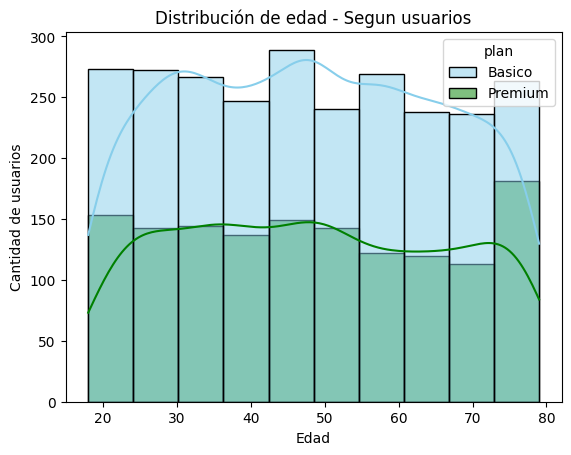

In [ ]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x='age', bins=10, hue='plan',
             palette=['skyblue','green'], kde=True)
plt.xlabel('Edad')
plt.ylabel('Cantidad de usuarios')
plt.title('Distribución de edad - Segun usuarios')
plt.show()

💡Insights:
- Distribución agrupada, en un rango de 18 a 76, sin valores extremos. Tendencia del plan basico por encima del plan premium.

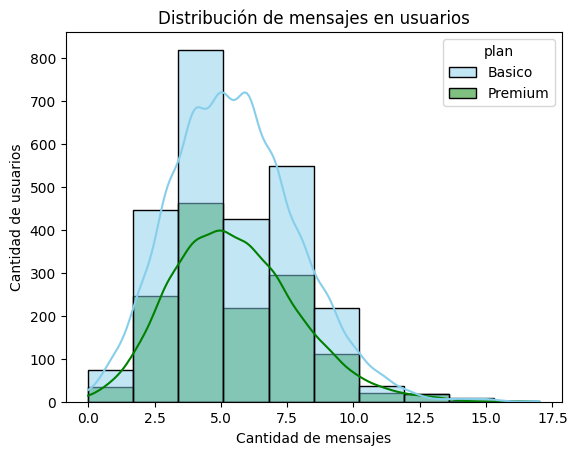

In [ ]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x='cant_mensajes', bins=10, hue='plan',
             palette=['skyblue','green'], kde=True)
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Cantidad de usuarios')
plt.title('Distribución de mensajes en usuarios')
plt.show()

💡Insights:
- Dispersion cons sesgo a la derecha en donde se evidencia que existen pocos usuarios con alta candidad de mensajes en el uso del servicio destacandose en el plan premium. Grupos distintos varios picos, en donde se resalta que la cantidad de mensajes 5 se encuentran en la mayor cantidad de usuarios llegando casi a 800 para el plan basico y 450 para el plan premium.

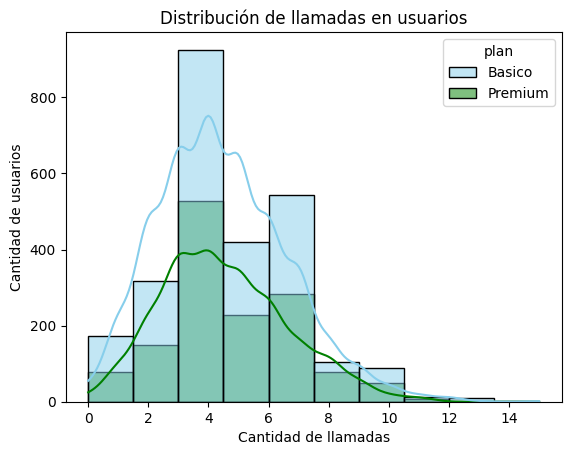

In [ ]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_llamadas', bins=10, hue='plan',
             palette=['skyblue','green'], kde=True)
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Cantidad de usuarios')
plt.title('Distribución de llamadas en usuarios')
plt.show()

💡Insights:
- Distribución con sesgo a la derecha indicando pocos usuarios con mayor cantidad de llamadas del plan premium similar a la cantidad de mensaje de texto, asi mismo se relaciona 4 llamadas frecuentes como el dato de moda de la distribucion en la mayor contidad de usuarios. existen llamadas en 0 y llamadas casi en frecuencias de 14 registros.

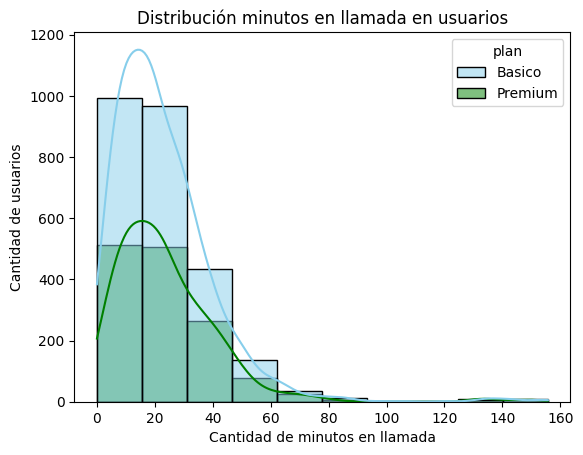

In [ ]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', bins=10, hue='plan',
             palette=['skyblue','green'], kde=True)
plt.xlabel('Cantidad de minutos en llamada')
plt.ylabel('Cantidad de usuarios')
plt.title('Distribución minutos en llamada en usuarios')
plt.show()

💡Insights:
- Sesgo a la derecha con salto de informacion en valores de min en llamada den un rando de 85-120 aproximadamente, e informacion registrada en 120-150 minutos de llamada en pocos usuarios con plan premium. el dato de moda esta entre 0-20 en donde e indica que la mayoria suele durar menos de 20 minutos en su llamada tanto para plan premium y basico.

### 5.2 Identificación de Outliers

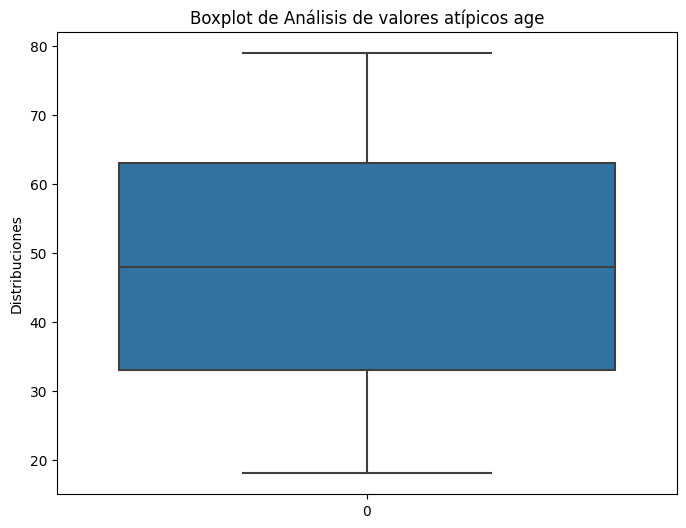

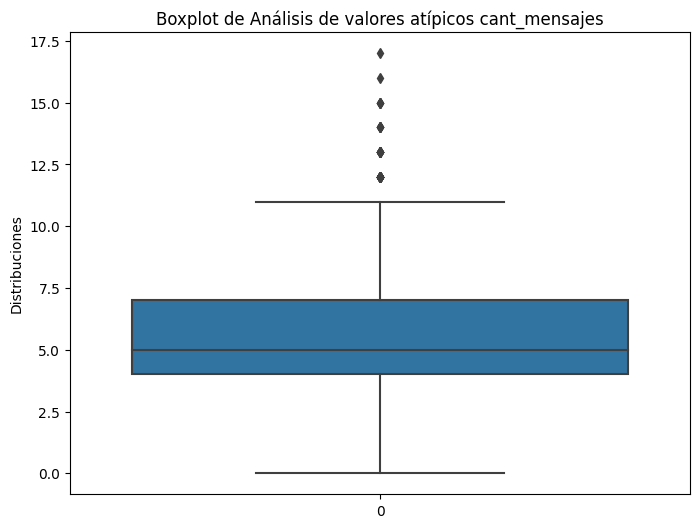

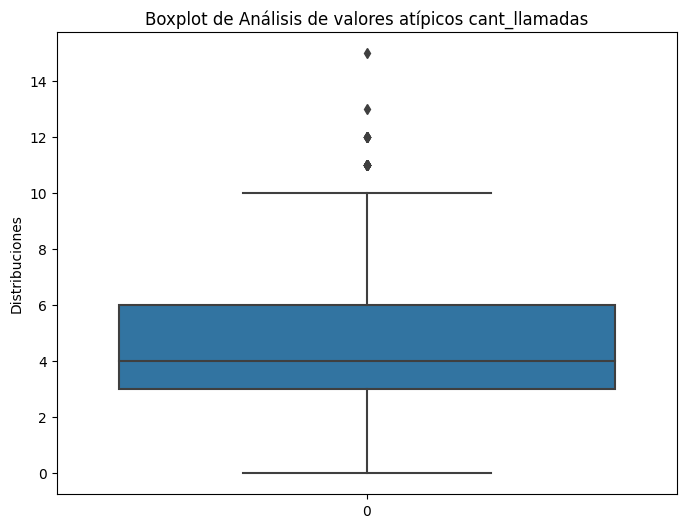

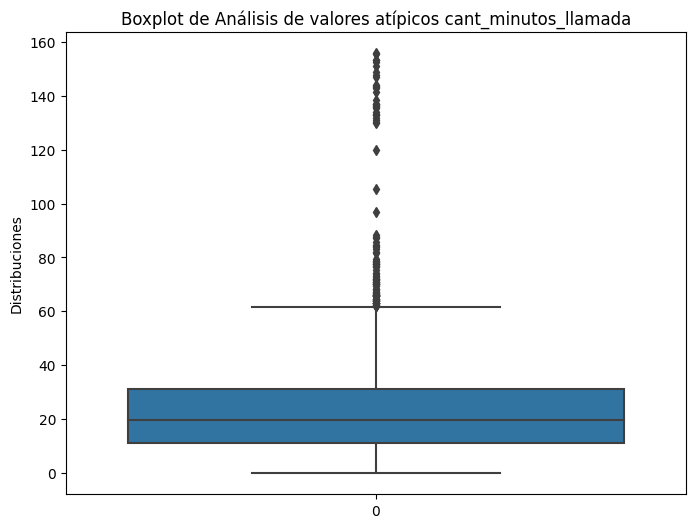

In [ ]:
# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for box in columnas_numericas:
    plt.figure(figsize=(8, 6))
    sns.boxplot(data=user_profile[box])
    plt.title(f'Boxplot de Análisis de valores atípicos {box}')
    plt.ylabel('Distribuciones')
    plt.show()

💡Insights:
- Age: No presenta Outliers, desde un principio las metricas mostraron los valores max y min de manera coherente, razon que se refleja en el diagrama, Q2 de casi 50.
- cant_mensajes: presenta valores atipicos leves, los cuales representan a esos pocos clientes que utililzan mayor cantidad de mensajes en su tipo de servicio, Q2 50.
- cant_llamadas: si existen valores atipicos leves y otro extremo que se encuentra superior al registro de 14 llamadas, lo cual indica que pocos usuarios frecuentan la gran cantidad de llamadas Q2 de 4.
- cant_minutos_llamada: registra valores atipicos extremos muy alejados del Cuartil superior Q3 60.

In [ ]:
# Calcular límites con el método IQR
columnas_limites = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
for columna in columnas_limites:
    # Calcular cuartiles
    Q1 = user_profile[columna].quantile(0.25)
    Q3 = user_profile[columna].quantile(0.75)
    IQR = Q3 - Q1

    # Calcular límites
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    print(f"Columna {columna}:")
    print(f"  Q1: {Q1}")
    print(f"  Q3: {Q3}")
    print(f"  IQR: {IQR}")
    print(f"  Límites: [{limite_inferior}, {limite_superior}]")
    print("-" * 40)

Columna age:
  Q1: 33.0
  Q3: 63.0
  IQR: 30.0
  Límites: [-12.0, 108.0]
----------------------------------------
Columna cant_mensajes:
  Q1: 4.0
  Q3: 7.0
  IQR: 3.0
  Límites: [-0.5, 11.5]
----------------------------------------
Columna cant_llamadas:
  Q1: 3.0
  Q3: 6.0
  IQR: 3.0
  Límites: [-1.5, 10.5]
----------------------------------------
Columna cant_minutos_llamada:
  Q1: 11.12
  Q3: 31.415
  IQR: 20.295
  Límites: [-19.322500000000005, 61.8575]
----------------------------------------


In [ ]:

# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()



,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000,3999.000000
mean,48.138285,5.524381,4.478120,23.317054
std,17.691541,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [ ]:


# Calcula percentiles para ambas variables
percentil_99_mensajes = user_profile['cant_mensajes'].quantile(0.99)
percentil_99_llamadas = user_profile['cant_llamadas'].quantile(0.99)
percentil_99_minutos = user_profile['cant_minutos_llamada'].quantile(0.99)
print(f"P99 mensajes: {percentil_99_mensajes}")
print(f"P99 llamadas: {percentil_99_llamadas}")
print(f"P99 minutos: {percentil_99_minutos}")



P99 mensajes: 12.0
P99 llamadas: 10.0
P99 minutos: 82.19759999999998


---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

In [ ]:

user_profile['grupo_uso'] = np.where(
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),
    'Bajo uso',
    np.where(
        (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10),
        'Uso medio',
        'Alto uso'
    )
)


In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,año_registro,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,2022,7,3,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,2022,5,10,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,2022,5,2,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,2022,11,3,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,2022,4,3,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

In [ ]:
# Crear columna grupo_edad
user_profile['grupo_edad'] = np.where(
    user_profile['age'] < 30, 'Joven',
    np.where(
        user_profile['age'] < 60, 'Adulto', 'Adulto Mayor'
    )
)

In [ ]:

# verificar cambios
user_profile.head()


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,año_registro,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,2022,7,3,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,2022,5,10,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,2022,5,2,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,2022,11,3,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,2022,4,3,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

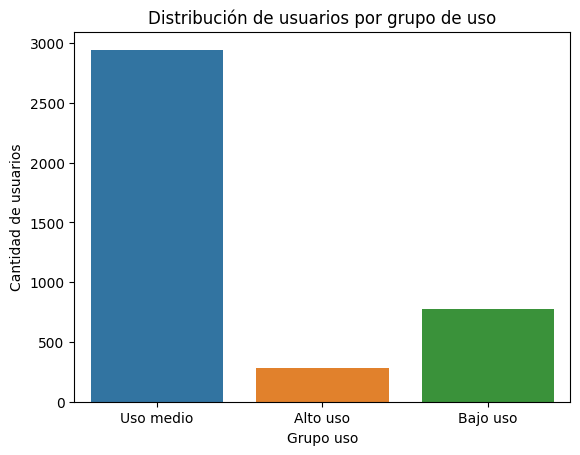

In [ ]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso')
plt.title('Distribución de usuarios por grupo de uso')
plt.xlabel('Grupo uso')
plt.ylabel('Cantidad de usuarios')
plt.show()

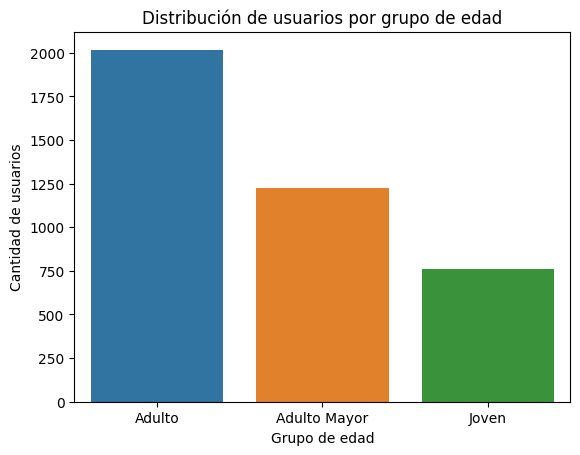

In [ ]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad')
plt.title('Distribución de usuarios por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de usuarios')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Tipo de dato erroneo en columnas de date.  
- valores nulos o faltantes en columnas Churn_date (no fue relevante para el analisis debido a que esta columna no fue parte del analisis)
- Valores como falsos nulos en ciudad.


🔍 **Segmentos por Edad**
- Se puede observar que el uso medio es el grupo mas predominante en esta segmentacion: llamadas < 10 y mensajes < 10 en casi 3000 usuarios. Y que solo un grupo especifico de usuarios realizan alto uso aproximado de 250
  
🔍 **segmentos por Nivel de Uso**
- Se observa que los adultos son los que mas utilizan el servicio, y en una mas baja proporcion lo jovenes.


➡️ Esto sugiere que, probablemente los jovenes usan otros medios de comunicacion como aplicaciones (facebook, instagram, snapchat, etc) como uso en su comunicacion con respecto a las llamadas y/o mensajes de texto, por el contrario de la poblacion adulta debido al avance de la tecnologia es mas sencillo emplear estos servicios.

Asi mismo, existe un calante que es menor a 10 llamadas y 10 mensajes de usuarios, en la mayoria de usuarios en donde al menos casi el 90% se encuentra en este rango.


💡 **Recomendaciones**
- Agregar otros tipos de usos para la comunicacion, pueden ser datos de cosumo en redes sociales etc.
- revisar los valores que corresponden a minutos de llamada en el el atributo duration con el fin de corroborar si este esta realizando la captura de la manera adecuada.

Link a repositorio público del proyecto: `https://github.com/Mariamonsalve1305/sprint7-final-project`